In [1]:
# ── Parte 3 · Flow Shop ── Célula 1: ler uma instância CSV ────────────────
const DATA_DIR = raw"C:\Users\Saidk\OneDrive\Desktop\Mestrado\optimization2026\materiais\AULA06\fssp_problems"

"""
    ler_instancia(caminho) -> (p, n, m)

Lê um CSV no formato problem_{m}m_{n}j.csv (jobs nas linhas, máquinas nas colunas).
Devolve:
  p :: Matrix{Int}  — p[j, i] = tempo do job j na máquina i
  n :: Int          — número de jobs
  m :: Int          — número de máquinas
"""
function ler_instancia(caminho::AbstractString)
    linhas = readlines(caminho)                        # tira \n (e \r do Windows)
    linhas = filter(l -> !isempty(strip(l)), linhas)   # descarta linhas vazias
    corpo  = linhas[2:end]                              # 1ª linha é cabeçalho: descarta
    n = length(corpo)
    m = length(split(strip(corpo[1]), ',')) - 1        # -1 tira a coluna do rótulo Jx
    p = Matrix{Int}(undef, n, m)
    for (j, linha) in enumerate(corpo)
        campos = split(strip(linha), ',')
        for i in 1:m
            p[j, i] = parse(Int, strip(campos[i + 1])) # +1 pula o rótulo Jx
        end
    end
    return p, n, m
end

# Teste com a instância 3×10 (a mesma do slide)
caminho = joinpath(DATA_DIR, "problem_3m_10j.csv")
p, n, m = ler_instancia(caminho)

println("Instância: $n jobs × $m máquinas")
println("Matriz de tempos p[job, máquina]:")
display(p)

Instância: 10 jobs × 3 máquinas
Matriz de tempos p[job, máquina]:


10×3 Matrix{Int64}:
 17  15  14
 18  16   6
  8  14  12
  1  15  10
 18  13  14
 15   9   1
 15  14  10
  3   5   4
  3   7  13
  3  16  17

In [2]:
# ── Célula 2: pisos (limites inferiores) do makespan ──────────────────────
"""
    pisos(p) -> (piso_job, piso_maquina, piso)

Dois "chões" que o makespan nunca pode furar:
  piso_job     = maior soma de uma LINHA  (o job mais longo passa por todas as máquinas)
  piso_maquina = maior soma de uma COLUNA (a máquina + ocupada processa todos os jobs)
  piso         = o maior dos dois
"""
function pisos(p::Matrix{Int})
    somas_job     = vec(sum(p, dims=2))   # soma de cada linha (job)
    somas_maquina = vec(sum(p, dims=1))   # soma de cada coluna (máquina)
    piso_job      = maximum(somas_job)
    piso_maquina  = maximum(somas_maquina)
    return piso_job, piso_maquina, max(piso_job, piso_maquina)
end

pj, pm, piso = pisos(p)
println("Piso pelo job mais longo    : $pj  (linha mais pesada)")
println("Piso pela máquina + ocupada : $pm  (coluna mais pesada)")
println("PISO do makespan            : $piso")
println("→ Qualquer solução válida terá makespan ≥ $piso.")

Piso pelo job mais longo    : 46  (linha mais pesada)
Piso pela máquina + ocupada : 124  (coluna mais pesada)
PISO do makespan            : 124
→ Qualquer solução válida terá makespan ≥ 124.


In [3]:
# ── Célula 3: piso afiado (limite inferior por máquina) ───────────────────
"""
    piso_afiado(p) -> (lb, detalhe)

Para CADA máquina i, um piso mais forte:
  (menor tempo ANTES de i)  +  (soma da coluna i)  +  (menor tempo DEPOIS de i)
A máquina processa todos os jobs (a coluna), mas só começa quando o primeiro job
chega (aquecimento mínimo) e ainda há escoamento depois do último (rabo mínimo).
O piso afiado é o MAIOR desses valores entre as máquinas.
"""
function piso_afiado(p::Matrix{Int})
    n, m = size(p)
    melhor  = 0
    detalhe = NamedTuple[]
    for i in 1:m
        antes  = i == 1 ? zeros(Int, n) : vec(sum(p[:, 1:i-1], dims=2))  # tempo antes de i, por job
        depois = i == m ? zeros(Int, n) : vec(sum(p[:, i+1:m], dims=2))  # tempo depois de i, por job
        col    = sum(p[:, i])                                            # trabalho total da máquina i
        lb_i   = minimum(antes) + col + minimum(depois)
        push!(detalhe, (maquina=i, antes=minimum(antes), trabalho=col, depois=minimum(depois), lb=lb_i))
        melhor = max(melhor, lb_i)
    end
    return melhor, detalhe
end

lb, det = piso_afiado(p)
println("Piso afiado por máquina:")
for d in det
    println("  M$(d.maquina):  $(d.antes) (antes)  +  $(d.trabalho) (trabalho)  +  $(d.depois) (depois)  =  $(d.lb)")
end
println("PISO AFIADO = $lb")

Piso afiado por máquina:
  M1:  0 (antes)  +  101 (trabalho)  +  9 (depois)  =  110
  M2:  1 (antes)  +  124 (trabalho)  +  1 (depois)  =  126
  M3:  8 (antes)  +  101 (trabalho)  +  0 (depois)  =  109
PISO AFIADO = 126


In [4]:
# ── Célula 4: cria o modelo e declara as variáveis ────────────────────────
# (precisa ter rodado as células 1–3 antes: p, n, m já estão na memória)
using JuMP, HiGHS

modelo = Model(HiGHS.Optimizer)      # modelo vazio, ligado ao solver HiGHS

# x[j,k] = 1 se o job j ocupa a posição k da fila  (grade n×n)
@variable(modelo, x[1:n, 1:n], Bin)

# C[k,i] = tempo em que a posição k termina na máquina i  (≥ 0)
@variable(modelo, C[1:n, 1:m] >= 0)

println("Modelo criado com o HiGHS.")
println("  binárias  x[j,k] : ", n*n, "   (grade ", n, "×", n, ")")
println("  contínuas C[k,i] : ", n*m)
println("  total de variáveis: ", num_variables(modelo))

Modelo criado com o HiGHS.
  binárias  x[j,k] : 100   (grade 10×10)
  contínuas C[k,i] : 30
  total de variáveis: 130


In [5]:
# ── Célula 5: restrições de atribuição (a permutação) ─────────────────────
# cada JOB ocupa exatamente uma posição   →  soma de cada LINHA da grade = 1
@constraint(modelo, cada_job[j=1:n], sum(x[j,k] for k in 1:n) == 1)

# cada POSIÇÃO recebe exatamente um job   →  soma de cada COLUNA da grade = 1
@constraint(modelo, cada_pos[k=1:n], sum(x[j,k] for j in 1:n) == 1)

println("Restrições de atribuição adicionadas.")
println("  'cada job'     : ", n, " restrições (uma por linha)")
println("  'cada posição' : ", n, " restrições (uma por coluna)")
println("  restrições afim no modelo até aqui: ",
        num_constraints(modelo; count_variable_in_set_constraints=false))

Restrições de atribuição adicionadas.
  'cada job'     : 10 restrições (uma por linha)
  'cada posição' : 10 restrições (uma por coluna)
  restrições afim no modelo até aqui: 20


In [6]:
# ── Célula 6: encadeamento dos tempos (as recursões da escada) ────────────

# pbar[k,i] = tempo do job que ocupa a posição k, na máquina i.
# É a soma-seletora: só o x[·,k] que vale 1 "acende" o p do job certo.
@expression(modelo, pbar[k=1:n, i=1:m], sum(x[j,k] * p[j,i] for j in 1:n))

# Recursão 1 — MÁQUINA LIVRE: a posição k só começa na máquina i depois que
# a posição anterior (k-1) terminou NESSA MESMA máquina.
@constraint(modelo, maq_livre[k=2:n, i=1:m], C[k,i] >= C[k-1,i] + pbar[k,i])

# Recursão 2 — JOB AVANÇA: a posição k só começa na máquina i depois que ela
# mesma terminou na máquina ANTERIOR (i-1).
@constraint(modelo, job_avanca[k=1:n, i=2:m], C[k,i] >= C[k,i-1] + pbar[k,i])

# Caso base: a 1ª posição na 1ª máquina começa em 0, logo termina em pbar[1,1].
@constraint(modelo, base, C[1,1] >= pbar[1,1])

println("Recursões de tempo adicionadas.")
println("  'maq_livre'  : ", (n-1)*m, " restrições")
println("  'job_avanca' : ", n*(m-1), " restrições")
println("  'base'       : 1 restrição")
println("  restrições afim no modelo até aqui: ",
        num_constraints(modelo; count_variable_in_set_constraints=false))

Recursões de tempo adicionadas.
  'maq_livre'  : 27 restrições
  'job_avanca' : 20 restrições
  'base'       : 1 restrição
  restrições afim no modelo até aqui: 68


In [7]:
# ── Célula 7: objetivo + resolve + checagens de sanidade ──────────────────
# makespan = fim da última posição (n) na última máquina (m)
@objective(modelo, Min, C[n, m])

optimize!(modelo)

# --- captura automática dos resultados (nada de transcrever à mão) ---
status   = termination_status(modelo)
makespan = objective_value(modelo)
tempo    = solve_time(modelo)
gap      = relative_gap(modelo)

println("status   : ", status)
println("makespan : ", makespan)
println("tempo    : ", round(tempo, digits=3), " s")
println("gap      : ", round(100*gap, digits=2), " %")

# --- sanidade: o makespan NUNCA pode furar o piso afiado (126) ---
@assert makespan >= lb - 1e-6  "BUG: makespan $(makespan) abaixo do piso $(lb)!"
println("\n✓ sanidade: makespan ($(round(makespan))) ≥ piso afiado ($lb) — ok")
if round(makespan) == lb
    println("✓ makespan == piso afiado: solução PROVADAMENTE ótima (o piso encostou no teto)")
end

Running HiGHS 1.14.0 (git hash: 7df0786de3): Copyright (c) 2026 under Apache 2.0 license terms
Using BLAS: blastrampoline-5 
MIP has 68 rows; 130 cols; 775 nonzeros; 100 integer variables (100 binary)
Coefficient ranges:
  Matrix  [1e+00, 2e+01]
  Cost    [1e+00, 1e+00]
  Bound   [1e+00, 1e+00]
  RHS     [1e+00, 1e+00]
Presolving model
68 rows, 130 cols, 775 nonzeros 0s
54 rows, 116 cols, 639 nonzeros 0s
Presolve reductions: rows 54(-14); columns 116(-14); nonzeros 639(-136) 

Solving MIP model with:
   54 rows
   116 cols (100 binary, 0 integer, 0 implied int., 16 continuous, 0 domain fixed)
   639 nonzeros

Src: B => Branching; C => Central rounding; F => Feasibility pump; H => Heuristic;
     I => Shifting; J => Feasibility jump; L => Sub-MIP; P => Empty MIP; R => Randomized rounding;
     S => Solve LP; T => Evaluate node; U => Unbounded; X => User solution; Y => HiGHS solution;
     Z => ZI Round; l => Trivial lower; p => Trivial point; u => Trivial upper; z => Trivial zero

     

In [8]:
# ── Célula 8: calculadora de makespan de uma fila (a "escada") ────────────
"""
    makespan_da_fila(fila, p) -> Int

Dada uma permutação de jobs (vetor com os índices dos jobs na ordem da fila),
calcula o makespan encadeando os tempos — exatamente a escada do Gantt:
  C[k,i] = max(máquina livre, job chegou) + tempo do job dessa posição.
"""
function makespan_da_fila(fila::Vector{Int}, p::Matrix{Int})
    nn = length(fila)
    mm = size(p, 2)
    C = zeros(Int, nn, mm)
    for k in 1:nn                                 # k = posição na fila
        j = fila[k]                               # job que está nessa posição
        for i in 1:mm                             # i = máquina
            maq_livre  = k == 1 ? 0 : C[k-1, i]   # a posição anterior já saiu daqui?
            job_chegou = i == 1 ? 0 : C[k, i-1]   # o job já terminou na máq anterior?
            C[k, i] = max(maq_livre, job_chegou) + p[j, i]
        end
    end
    return C[nn, mm]
end

# --- validação independente: extrai a fila ótima do solver e recalcula ---
xval = value.(x)
fila_otima = Vector{Int}(undef, n)
for k in 1:n, j in 1:n
    if xval[j, k] > 0.5
        fila_otima[k] = j
    end
end

ms = makespan_da_fila(fila_otima, p)
println("Fila ótima do solver (jobs em ordem) : ", fila_otima)
println("Makespan recalculado pela escada     : ", ms)
println("Makespan do solver                   : ", Int(round(makespan)))

@assert ms == Int(round(makespan)) "As duas contas divergiram — tem bug em algum lado!"
println("\n✓ bateu: calculadora independente confirma o solver ($(ms))")

Fila ótima do solver (jobs em ordem) : [4, 8, 9, 3, 5, 10, 1, 7, 2, 6]
Makespan recalculado pela escada     : 126
Makespan do solver                   : 126

✓ bateu: calculadora independente confirma o solver (126)


In [9]:
# ── Célula 9: heurística NEH ──────────────────────────────────────────────
"""
    neh(p) -> (fila, ms)

Nawaz–Enscore–Ham:
  Movimento 1: ordena os jobs por tempo total (soma da linha) DECRESCENTE.
  Movimento 2: insere um a um na posição que dá o menor makespan parcial.
Devolve a fila construída e seu makespan.
"""
function neh(p::Matrix{Int})
    nn = size(p, 1)

    # Movimento 1 — ordena por peso (soma da linha) decrescente
    pesos = vec(sum(p, dims=2))
    ordem = sortperm(pesos, rev=true)      # índices dos jobs, do mais pesado ao mais leve

    # Movimento 2 — inserção gulosa
    fila = [ordem[1]]                      # começa só com o job mais pesado
    for t in 2:nn
        job = ordem[t]                     # próximo job a inserir
        melhor_fila = Int[]
        melhor_ms   = typemax(Int)         # "infinito": qualquer makespan real é menor
        for pos in 1:length(fila)+1        # testa TODOS os buracos possíveis
            candidata = copy(fila)
            insert!(candidata, pos, job)   # enfia o job na posição 'pos'
            ms = makespan_da_fila(candidata, p)
            if ms < melhor_ms              # ficou com a melhor inserção
                melhor_ms   = ms
                melhor_fila = candidata
            end
        end
        fila = melhor_fila                 # congela a escolha e passa pro próximo job
    end

    return fila, makespan_da_fila(fila, p)
end

# --- roda o NEH na 3×10 e compara com o ótimo (126) ---
fila_neh, ms_neh = neh(p)
println("Fila do NEH      : ", fila_neh)
println("Makespan NEH     : ", ms_neh)
println("Ótimo (solver)   : ", Int(round(makespan)))
folga = ms_neh - Int(round(makespan))
println("Folga NEH−ótimo  : ", folga, "  (", round(100*folga/makespan, digits=2), "%)")

@assert ms_neh >= lb - 1e-6  "BUG: NEH abaixo do piso $lb!"
println("✓ sanidade: NEH ($ms_neh) ≥ piso afiado ($lb) — ok")

Fila do NEH      : [4, 8, 9, 10, 3, 7, 1, 5, 2, 6]
Makespan NEH     : 126
Ótimo (solver)   : 126
Folga NEH−ótimo  : 0  (0.0%)
✓ sanidade: NEH (126) ≥ piso afiado (126) — ok


In [10]:
# ── Célula 10: roda exato + NEH em todas as 7 instâncias ──────────────────
using Printf

const TIME_LIMIT = 120.0   # segundos por instância

# monta e resolve o MILO posicional para uma instância (p, n, m) — células 4–7 empacotadas
function resolve_exato(p, n, m; time_limit=TIME_LIMIT)
    mod = Model(HiGHS.Optimizer)
    set_optimizer_attribute(mod, "time_limit", time_limit)
    set_silent(mod)                                    # não despeja o log de cada uma
    @variable(mod, x[1:n, 1:n], Bin)
    @variable(mod, C[1:n, 1:m] >= 0)
    @constraint(mod, [j=1:n], sum(x[j,k] for k in 1:n) == 1)
    @constraint(mod, [k=1:n], sum(x[j,k] for j in 1:n) == 1)
    @expression(mod, pbar[k=1:n, i=1:m], sum(x[j,k]*p[j,i] for j in 1:n))
    @constraint(mod, [k=2:n, i=1:m], C[k,i] >= C[k-1,i] + pbar[k,i])
    @constraint(mod, [k=1:n, i=2:m], C[k,i] >= C[k,i-1] + pbar[k,i])
    @constraint(mod, C[1,1] >= pbar[1,1])
    @objective(mod, Min, C[n,m])
    optimize!(mod)
    return objective_value(mod), solve_time(mod),
           relative_gap(mod), termination_status(mod)
end

arquivos = ["problem_3m_10j.csv", "problem_3m_20j.csv", "problem_5m_10j.csv",
            "problem_5m_20j.csv", "problem_5m_30j.csv", "problem_8m_10j.csv",
            "problem_10m_20j.csv"]

# coleta tudo numa lista de NamedTuples (vira tabela/CSV depois, sem transcrição)
resultados = NamedTuple[]
for arq in arquivos
    pi, ni, mi = ler_instancia(joinpath(DATA_DIR, arq))
    _, _, lbi          = piso_afiado(pi)
    ms_ex, t, g, st    = resolve_exato(pi, ni, mi)
    _, ms_neh          = neh(pi)
    ms_ex_int = Int(round(ms_ex))

    # sanidades: nenhum método pode furar o piso; NEH nunca melhor que o ótimo provado
    @assert ms_ex_int  >= lbi - 1e-6  "$arq: exato abaixo do piso!"
    @assert ms_neh     >= lbi         "$arq: NEH abaixo do piso!"

    push!(resultados, (inst="$(mi)×$(ni)", n=ni, m=mi, piso=lbi,
                       exato=ms_ex_int, neh=ms_neh,
                       gap=round(100*g, digits=1), tempo=round(t, digits=2),
                       status=string(st)))
    @printf("%-8s  piso %4d  exato %4d  NEH %4d  gap %5.1f%%  %6.2fs  %s\n",
            "$(mi)×$(ni)", lbi, ms_ex_int, ms_neh, 100*g, t, st)
end

println("\n✓ rodada completa — ", length(resultados), " instâncias, sem violar nenhum piso")

LoadError: BoundsError: attempt to access Tuple{Int64, Vector{NamedTuple}} at index [3]

In [12]:
# ── Célula 10: roda exato + NEH em todas as 7 instâncias (corrigida) ──────
using Printf

const TIME_LIMIT = 120.0   # segundos por instância

# monta e resolve o MILO posicional para uma instância (p, n, m) — células 4–7 empacotadas
function resolve_exato(p, n, m; time_limit=TIME_LIMIT)
    mod = Model(HiGHS.Optimizer)
    set_optimizer_attribute(mod, "time_limit", time_limit)
    set_silent(mod)                                    # não despeja o log de cada uma
    @variable(mod, x[1:n, 1:n], Bin)
    @variable(mod, C[1:n, 1:m] >= 0)
    @constraint(mod, [j=1:n], sum(x[j,k] for k in 1:n) == 1)
    @constraint(mod, [k=1:n], sum(x[j,k] for j in 1:n) == 1)
    @expression(mod, pbar[k=1:n, i=1:m], sum(x[j,k]*p[j,i] for j in 1:n))
    @constraint(mod, [k=2:n, i=1:m], C[k,i] >= C[k-1,i] + pbar[k,i])
    @constraint(mod, [k=1:n, i=2:m], C[k,i] >= C[k,i-1] + pbar[k,i])
    @constraint(mod, C[1,1] >= pbar[1,1])
    @objective(mod, Min, C[n,m])
    optimize!(mod)
    return objective_value(mod), solve_time(mod),
           relative_gap(mod), termination_status(mod)
end

arquivos = ["problem_3m_10j.csv", "problem_3m_20j.csv", "problem_5m_10j.csv",
            "problem_5m_20j.csv", "problem_5m_30j.csv", "problem_8m_10j.csv",
            "problem_10m_20j.csv"]

# coleta tudo numa lista de NamedTuples (vira tabela/CSV depois, sem transcrição)
resultados = NamedTuple[]
for arq in arquivos
    pI, nI, mI = ler_instancia(joinpath(DATA_DIR, arq))   # nomes sem conflito (pi é π!)
    _, _, lbI          = piso_afiado(pI)
    ms_ex, t, g, st    = resolve_exato(pI, nI, mI)
    _, ms_neh          = neh(pI)
    ms_ex_int = Int(round(ms_ex))

    # sanidades: nenhum método pode furar o piso; NEH nunca melhor que o ótimo provado
    @assert ms_ex_int  >= lbI - 1e-6  "$arq: exato abaixo do piso!"
    @assert ms_neh     >= lbI         "$arq: NEH abaixo do piso!"

    push!(resultados, (inst="$(mI)×$(nI)", n=nI, m=mI, piso=lbI,
                       exato=ms_ex_int, neh=ms_neh,
                       gap=round(100*g, digits=1), tempo=round(t, digits=2),
                       status=string(st)))
    @printf("%-8s  piso %4d  exato %4d  NEH %4d  gap %5.1f%%  %6.2fs  %s\n",
            "$(mI)×$(nI)", lbI, ms_ex_int, ms_neh, 100*g, t, st)
end

println("\n✓ rodada completa — ", length(resultados), " instâncias, sem violar nenhum piso")

LoadError: BoundsError: attempt to access Tuple{Int64, Vector{NamedTuple}} at index [3]

In [13]:
# ── Célula 10: roda exato + NEH em todas as 7 instâncias (corrigida de verdade) ──
using Printf

const TIME_LIMIT = 120.0   # segundos por instância

function resolve_exato(p, n, m; time_limit=TIME_LIMIT)
    mod = Model(HiGHS.Optimizer)
    set_optimizer_attribute(mod, "time_limit", time_limit)
    set_silent(mod)
    @variable(mod, x[1:n, 1:n], Bin)
    @variable(mod, C[1:n, 1:m] >= 0)
    @constraint(mod, [j=1:n], sum(x[j,k] for k in 1:n) == 1)
    @constraint(mod, [k=1:n], sum(x[j,k] for j in 1:n) == 1)
    @expression(mod, pbar[k=1:n, i=1:m], sum(x[j,k]*p[j,i] for j in 1:n))
    @constraint(mod, [k=2:n, i=1:m], C[k,i] >= C[k-1,i] + pbar[k,i])
    @constraint(mod, [k=1:n, i=2:m], C[k,i] >= C[k,i-1] + pbar[k,i])
    @constraint(mod, C[1,1] >= pbar[1,1])
    @objective(mod, Min, C[n,m])
    optimize!(mod)
    return objective_value(mod), solve_time(mod),
           relative_gap(mod), termination_status(mod)
end

arquivos = ["problem_3m_10j.csv", "problem_3m_20j.csv", "problem_5m_10j.csv",
            "problem_5m_20j.csv", "problem_5m_30j.csv", "problem_8m_10j.csv",
            "problem_10m_20j.csv"]

resultados = NamedTuple[]
for arq in arquivos
    pI, nI, mI = ler_instancia(joinpath(DATA_DIR, arq))
    lbI, _          = piso_afiado(pI)                 # ← AQUI: piso é o 1º de 2 valores
    ms_ex, t, g, st = resolve_exato(pI, nI, mI)
    _, ms_neh       = neh(pI)
    ms_ex_int = Int(round(ms_ex))

    @assert ms_ex_int >= lbI - 1e-6  "$arq: exato abaixo do piso!"
    @assert ms_neh    >= lbI         "$arq: NEH abaixo do piso!"

    push!(resultados, (inst="$(mI)×$(nI)", n=nI, m=mI, piso=lbI,
                       exato=ms_ex_int, neh=ms_neh,
                       gap=round(100*g, digits=1), tempo=round(t, digits=2),
                       status=string(st)))
    @printf("%-8s  piso %4d  exato %4d  NEH %4d  gap %5.1f%%  %6.2fs  %s\n",
            "$(mI)×$(nI)", lbI, ms_ex_int, ms_neh, 100*g, t, st)
end

println("\n✓ rodada completa — ", length(resultados), " instâncias, sem violar nenhum piso")

3×10      piso  126  exato  126  NEH  126  gap   0.0%    0.01s  OPTIMAL
3×20      piso  218  exato  218  NEH  218  gap   0.0%    0.10s  OPTIMAL
5×10      piso  126  exato  129  NEH  132  gap   0.0%    0.15s  OPTIMAL
5×20      piso  256  exato  263  NEH  269  gap   0.0%   13.46s  OPTIMAL
5×30      piso  327  exato  327  NEH  327  gap   0.0%    2.69s  OPTIMAL
8×10      piso  167  exato  187  NEH  197  gap   0.0%    7.75s  OPTIMAL
10×20     piso  278  exato  297  NEH  292  gap   5.5%  120.01s  TIME_LIMIT

✓ rodada completa — 7 instâncias, sem violar nenhum piso


In [14]:
# ── Célula 11: salva CSV + tabela final formatada ─────────────────────────

caminho_csv = joinpath(DATA_DIR, "resultados_flowshop.csv")

open(caminho_csv, "w") do io
    # cabeçalho
    println(io, "inst,n,m,piso,exato,neh,folga_neh,folga_neh_pct,gap_pct,tempo_s,status")
    for r in resultados
        folga     = r.neh - r.exato
        folga_pct = round(100*folga/r.exato, digits=1)
        println(io, join([r.inst, r.n, r.m, r.piso, r.exato, r.neh,
                          folga, folga_pct, r.gap, r.tempo, r.status], ","))
    end
end
println("✓ CSV salvo em: ", caminho_csv, "\n")

# --- tabela formatada na tela ---
@printf("%-7s | %4s | %5s | %5s | %6s | %8s | %6s | %8s | %s\n",
        "inst", "piso", "exato", "NEH", "folga", "folga%", "gap%", "tempo(s)", "status")
println(repeat("-", 78))
for r in resultados
    folga     = r.neh - r.exato
    folga_pct = round(100*folga/r.exato, digits=1)
    @printf("%-7s | %4d | %5d | %5d | %6d | %7.1f%% | %5.1f%% | %8.2f | %s\n",
            r.inst, r.piso, r.exato, r.neh, folga, folga_pct, r.gap, r.tempo, r.status)
end

✓ CSV salvo em: C:\Users\Saidk\OneDrive\Desktop\Mestrado\optimization2026\materiais\AULA06\fssp_problems\resultados_flowshop.csv

inst    | piso | exato |   NEH |  folga |   folga% |   gap% | tempo(s) | status
------------------------------------------------------------------------------
3×10    |  126 |   126 |   126 |      0 |     0.0% |   0.0% |     0.01 | OPTIMAL
3×20    |  218 |   218 |   218 |      0 |     0.0% |   0.0% |     0.10 | OPTIMAL
5×10    |  126 |   129 |   132 |      3 |     2.3% |   0.0% |     0.15 | OPTIMAL
5×20    |  256 |   263 |   269 |      6 |     2.3% |   0.0% |    13.46 | OPTIMAL
5×30    |  327 |   327 |   327 |      0 |     0.0% |   0.0% |     2.69 | OPTIMAL
8×10    |  167 |   187 |   197 |     10 |     5.3% |   0.0% |     7.75 | OPTIMAL
10×20   |  278 |   297 |   292 |     -5 |    -1.7% |   5.5% |   120.01 | TIME_LIMIT


✓ figura salva em: C:\Users\Saidk\OneDrive\Desktop\Mestrado\optimization2026\materiais\AULA06\fssp_problems\fig_tempo_x_tamanho.png


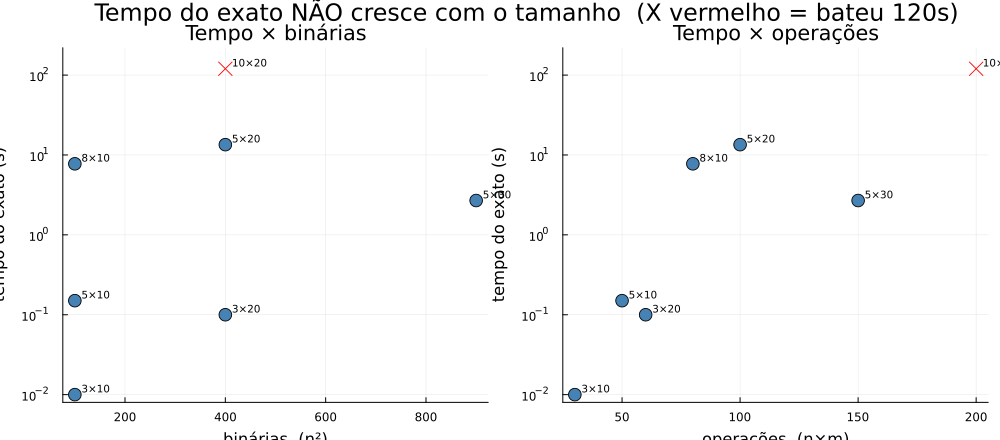

In [15]:
# ── Célula 12: gráfico tempo × tamanho (dois painéis) ─────────────────────
# 1ª vez com Plots precompila (alguns min). Se faltar o pacote: import Pkg; Pkg.add("Plots")
using Plots
gr()

# extrai os vetores direto de `resultados` (nada digitado à mão)
insts     = [r.inst        for r in resultados]
tempos    = [r.tempo       for r in resultados]
binarias  = [r.n^2         for r in resultados]   # n×n = binárias que o solver enxerga
operacoes = [r.n * r.m     for r in resultados]   # n×m = operações (tamanho físico)
no_limite = [r.status == "TIME_LIMIT" for r in resultados]

cores  = [nl ? :red : :steelblue for nl in no_limite]  # X vermelho = bateu o limite
formas = [nl ? :xcross : :circle for nl in no_limite]

function painel(xvals, xlabel, titulo)
    plt = scatter(xvals, tempos;
        markercolor=cores, markershape=formas, markersize=7,
        xlabel=xlabel, ylabel="tempo do exato (s)", title=titulo,
        yscale=:log10, ylims=(0.008, 220), legend=false, grid=true)
    for (x, y, nome) in zip(xvals, tempos, insts)   # rótulo de cada ponto
        annotate!(plt, x, y, text("  "*nome, 7, :left, :bottom))
    end
    return plt
end

p1 = painel(binarias,  "binárias  (n²)",     "Tempo × binárias")
p2 = painel(operacoes, "operações  (n×m)",   "Tempo × operações")

fig = plot(p1, p2; layout=(1,2), size=(1000,440),
           plot_title="Tempo do exato NÃO cresce com o tamanho  (X vermelho = bateu 120s)")

caminho_fig1 = joinpath(DATA_DIR, "fig_tempo_x_tamanho.png")
savefig(fig, caminho_fig1)
println("✓ figura salva em: ", caminho_fig1)
display(fig)

✓ figura salva em: C:\Users\Saidk\OneDrive\Desktop\Mestrado\optimization2026\materiais\AULA06\fssp_problems\fig_tempo_x_tamanho.png
Nota à parte: a 10×20 (n²=400, 200 operações) bateu o limite de 120 s,
gap 5.5%, status TIME_LIMIT — não entra no gráfico de tempo por não ter fechado.


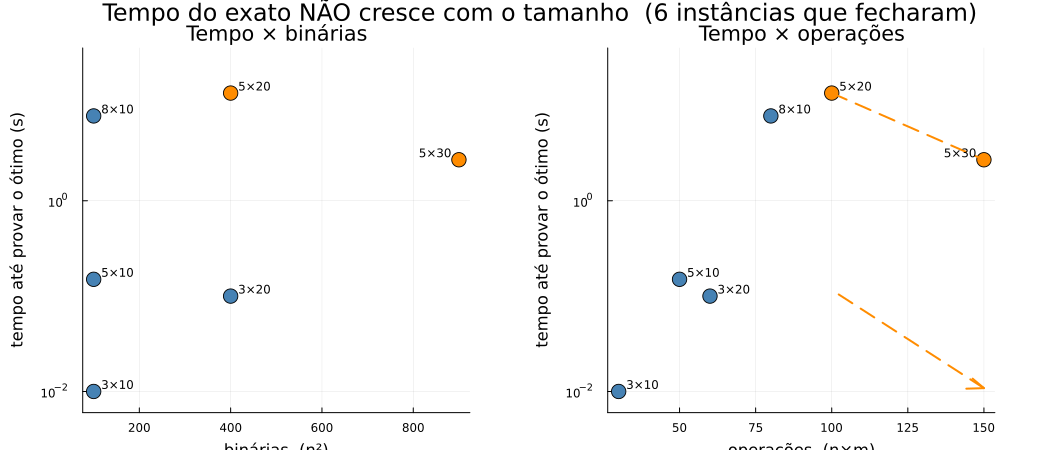

In [16]:
# ── Célula 12b: gráfico tempo × tamanho — só as 6 que FECHARAM ─────────────
using Plots
gr()

# filtra apenas as instâncias que fecharam no ótimo (tempo = tempo até PROVAR)
fechou = [r for r in resultados if r.status == "OPTIMAL"]

insts     = [r.inst    for r in fechou]
tempos    = [r.tempo   for r in fechou]
binarias  = [r.n^2     for r in fechou]
operacoes = [r.n * r.m for r in fechou]

# destaque do par 5×20 vs 5×30 (o argumento "mais jobs, menos tempo")
destaque  = [r.inst in ("5×20", "5×30") for r in fechou]
cores     = [d ? :darkorange : :steelblue for d in destaque]

function painel(xvals, xlabel, titulo)
    plt = scatter(xvals, tempos;
        markercolor=cores, markershape=:circle, markersize=8,
        xlabel=xlabel, ylabel="tempo até provar o ótimo (s)", title=titulo,
        yscale=:log10, ylims=(0.006, 40), legend=false, grid=true,
        right_margin=12Plots.mm, left_margin=6Plots.mm)
    xr = maximum(xvals) - minimum(xvals)
    for (x, y, nome) in zip(xvals, tempos, insts)
        # rótulo à esquerda se o ponto está no terço direito (não corta na borda)
        à_dir = x > minimum(xvals) + 0.66*xr
        annotate!(plt, x, y, text(à_dir ? nome*"  " : "  "*nome, 8,
                                  à_dir ? :right : :left, :bottom))
    end
    return plt
end

p1 = painel(binarias,  "binárias  (n²)",   "Tempo × binárias")
p2 = painel(operacoes, "operações  (n×m)", "Tempo × operações")

# seta no painel de operações ligando 5×20 → 5×30 (mais jobs, menos tempo)
i20 = findfirst(==("5×20"), insts); i30 = findfirst(==("5×30"), insts)
plot!(p2, [operacoes[i20], operacoes[i30]], [tempos[i20], tempos[i30]];
      arrow=true, color=:darkorange, linewidth=2, linestyle=:dash)

fig = plot(p1, p2; layout=(1,2), size=(1050,450),
    plot_title="Tempo do exato NÃO cresce com o tamanho  (6 instâncias que fecharam)")

caminho_fig1 = joinpath(DATA_DIR, "fig_tempo_x_tamanho.png")
savefig(fig, caminho_fig1)
println("✓ figura salva em: ", caminho_fig1)
println("Nota à parte: a 10×20 (n²=400, 200 operações) bateu o limite de 120 s,")
println("gap 5.5%, status TIME_LIMIT — não entra no gráfico de tempo por não ter fechado.")
display(fig)

In [17]:
# ── Célula 13: experimento na 10×20 — 4 rodadas comparadas ────────────────
# lê a 10×20 e prepara NEH + piso
p10, n10, m10 = ler_instancia(joinpath(DATA_DIR, "problem_10m_20j.csv"))
lb10, _        = piso_afiado(p10)
fila_neh10, ms_neh10 = neh(p10)
println("10×20 → NEH = $ms_neh10, piso afiado = $lb10\n")

# monta o modelo; recebe opções pra ligar warm start / piso / botões / tempo
function modelo_10x20(p, n, m; tempo, warm=false, usar_piso=false, botoes=false,
                      fila_ini=Int[], piso=0)
    mod = Model(HiGHS.Optimizer)
    set_optimizer_attribute(mod, "time_limit", tempo)
    set_silent(mod)
    if botoes
        set_optimizer_attribute(mod, "mip_rel_gap", 0.0)
        set_optimizer_attribute(mod, "mip_heuristic_effort", 0.2)
    end
    @variable(mod, x[1:n, 1:n], Bin)
    @variable(mod, C[1:n, 1:m] >= 0)
    @constraint(mod, [j=1:n], sum(x[j,k] for k in 1:n) == 1)
    @constraint(mod, [k=1:n], sum(x[j,k] for j in 1:n) == 1)
    @expression(mod, pbar[k=1:n, i=1:m], sum(x[j,k]*p[j,i] for j in 1:n))
    @constraint(mod, [k=2:n, i=1:m], C[k,i] >= C[k-1,i] + pbar[k,i])
    @constraint(mod, [k=1:n, i=2:m], C[k,i] >= C[k,i-1] + pbar[k,i])
    @constraint(mod, C[1,1] >= pbar[1,1])
    if usar_piso
        @constraint(mod, C[n,m] >= piso)          # limite inferior conhecido
    end
    if warm                                       # solução inicial = fila do NEH
        for k in 1:n, j in 1:n
            set_start_value(x[j,k], fila_ini[k] == j ? 1.0 : 0.0)
        end
    end
    @objective(mod, Min, C[n,m])
    optimize!(mod)
    return Int(round(objective_value(mod))), solve_time(mod),
           relative_gap(mod), termination_status(mod)
end

# as 4 rodadas
rodadas = [
    ("1. base (120s)",        (tempo=120.0,)),
    ("2. warm start",         (tempo=120.0, warm=true,  fila_ini=fila_neh10)),
    ("3. piso inferior",      (tempo=120.0, usar_piso=true, piso=lb10)),
    ("4. tudo + 300s+botões", (tempo=300.0, warm=true, usar_piso=true, botoes=true,
                               fila_ini=fila_neh10, piso=lb10)),
]

println(rpad("rodada", 24), " | ", "sol ", "| ", " gap  ", "| ", "tempo  ", "| status")
println(repeat("-", 68))
exp10 = NamedTuple[]
for (nome, kw) in rodadas
    sol, t, g, st = modelo_10x20(p10, n10, m10; kw...)
    push!(exp10, (rodada=nome, sol=sol, gap=round(100*g,digits=1),
                  tempo=round(t,digits=1), status=string(st)))
    @printf("%-24s | %4d | %5.1f%% | %6.1fs | %s\n", nome, sol, 100*g, t, string(st))
    @assert sol >= lb10 "$nome: solução abaixo do piso!"
end
println("\n✓ experimento concluído — referência: base deu 297, NEH deu $ms_neh10")

10×20 → NEH = 292, piso afiado = 278

rodada                   | sol |  gap  | tempo  | status
--------------------------------------------------------------------
1. base (120s)           |  297 |   5.5% |  120.0s | TIME_LIMIT
2. warm start            |  292 |   3.6% |  120.0s | TIME_LIMIT
3. piso inferior         |  290 |   3.1% |  120.0s | TIME_LIMIT
4. tudo + 300s+botões    |  292 |   3.2% |  300.0s | TIME_LIMIT

✓ experimento concluído — referência: base deu 297, NEH deu 292


In [18]:
# ── Célula 14: experimento das 4 rodadas em TODAS as 7 instâncias ─────────
# (renomeia a função da célula 13; é a mesma, serve pra qualquer instância)
modelo_flex = modelo_10x20

arquivos = ["problem_3m_10j.csv", "problem_3m_20j.csv", "problem_5m_10j.csv",
            "problem_5m_20j.csv", "problem_5m_30j.csv", "problem_8m_10j.csv",
            "problem_10m_20j.csv"]

exp_todos = NamedTuple[]
for arq in arquivos
    pI, nI, mI = ler_instancia(joinpath(DATA_DIR, arq))
    lbI, _        = piso_afiado(pI)
    filaI, msnehI = neh(pI)
    tag = "$(mI)×$(nI)"

    rodadas = [
        ("1.base",      (tempo=120.0,)),
        ("2.warm",      (tempo=120.0, warm=true, fila_ini=filaI)),
        ("3.piso",      (tempo=120.0, usar_piso=true, piso=lbI)),
        ("4.tudo+300s", (tempo=300.0, warm=true, usar_piso=true, botoes=true,
                         fila_ini=filaI, piso=lbI)),
    ]

    println("\n── $tag  (NEH=$msnehI, piso=$lbI) ", repeat("─", 30))
    @printf("%-12s | %4s | %5s | %7s | %s\n", "rodada", "sol", "gap", "tempo", "status")
    for (nome, kw) in rodadas
        sol, t, g, st = modelo_flex(pI, nI, mI; kw...)
        push!(exp_todos, (inst=tag, rodada=nome, sol=sol, gap=round(100*g,digits=1),
                          tempo=round(t,digits=1), status=string(st)))
        @printf("%-12s | %4d | %4.1f%% | %6.1fs | %s\n", nome, sol, 100*g, t, string(st))
        @assert sol >= lbI "$tag/$nome: solução abaixo do piso!"
    end
end

# salva o experimento inteiro em CSV
caminho_exp = joinpath(DATA_DIR, "experimento_4rodadas.csv")
open(caminho_exp, "w") do io
    println(io, "inst,rodada,sol,gap_pct,tempo_s,status")
    for r in exp_todos
        println(io, join([r.inst, r.rodada, r.sol, r.gap, r.tempo, r.status], ","))
    end
end
println("\n✓ experimento completo salvo em: ", caminho_exp)
println("  ", length(exp_todos), " execuções (7 instâncias × 4 rodadas)")


── 3×10  (NEH=126, piso=126) ──────────────────────────────
rodada       |  sol |   gap |   tempo | status
1.base       |  126 |  0.0% |    0.0s | OPTIMAL
2.warm       |  126 |  0.0% |    0.0s | OPTIMAL
3.piso       |  126 |  0.0% |    0.0s | OPTIMAL
4.tudo+300s  |  126 |  0.0% |    0.0s | OPTIMAL

── 3×20  (NEH=218, piso=218) ──────────────────────────────
rodada       |  sol |   gap |   tempo | status
1.base       |  218 |  0.0% |    0.1s | OPTIMAL
2.warm       |  218 |  0.0% |    0.0s | OPTIMAL
3.piso       |  218 |  0.0% |    0.4s | OPTIMAL
4.tudo+300s  |  218 |  0.0% |    0.0s | OPTIMAL

── 5×10  (NEH=132, piso=126) ──────────────────────────────
rodada       |  sol |   gap |   tempo | status
1.base       |  129 |  0.0% |    0.1s | OPTIMAL
2.warm       |  129 |  0.0% |    0.1s | OPTIMAL
3.piso       |  129 |  0.0% |    0.1s | OPTIMAL
4.tudo+300s  |  129 |  0.0% |    0.1s | OPTIMAL

── 5×20  (NEH=269, piso=256) ──────────────────────────────
rodada       |  sol |   gap |   tempo |

✓ figura salva em: C:\Users\Saidk\OneDrive\Desktop\Mestrado\optimization2026\materiais\AULA06\fssp_problems\fig_qualidade_neh.png
Folgas por instância (%): [0.0, 0.0, 2.3, 2.3, 0.0, 5.3, -1.7]


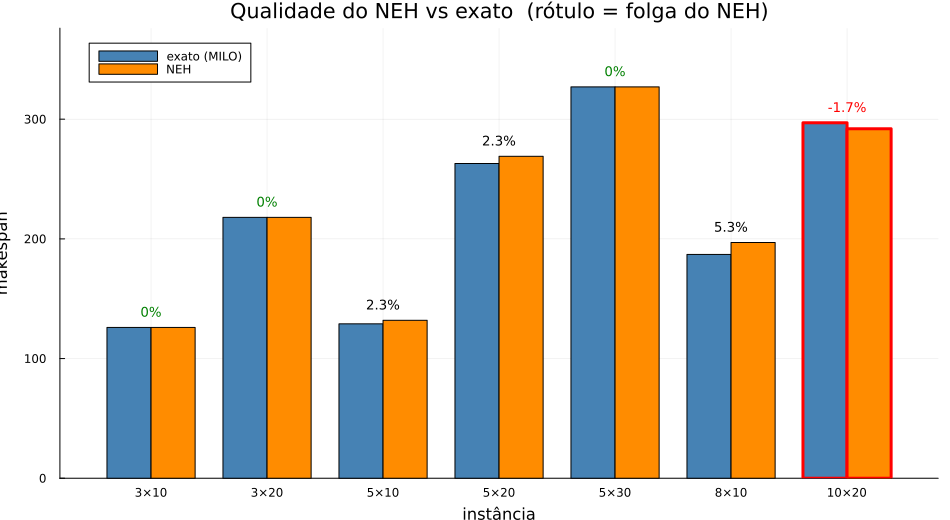

In [19]:
# ── Célula 15: gráfico de qualidade do NEH vs exato ───────────────────────
using Plots
gr()

# puxa tudo de `resultados` (nada digitado à mão)
insts  = [r.inst  for r in resultados]
exatos = [r.exato for r in resultados]
nehs   = [r.neh   for r in resultados]
folgas = [round(100*(r.neh - r.exato)/r.exato, digits=1) for r in resultados]
naofechou = [r.status == "TIME_LIMIT" for r in resultados]

nI = length(insts)
xs = 1:nI
larg = 0.38

# barras lado a lado: exato à esquerda, NEH à direita de cada instância
plt = bar(xs .- larg/2, exatos; bar_width=larg, label="exato (MILO)",
          color=:steelblue, legend=:topleft,
          xticks=(xs, insts), xlabel="instância", ylabel="makespan",
          title="Qualidade do NEH vs exato  (rótulo = folga do NEH)",
          size=(950,520), ylims=(0, maximum(nehs)*1.15))
bar!(plt, xs .+ larg/2, nehs; bar_width=larg, label="NEH", color=:darkorange)

# destaca a 10×20 (não fechou) com contorno vermelho grosso nas duas barras
for k in 1:nI
    if naofechou[k]
        bar!(plt, [xs[k]-larg/2], [exatos[k]]; bar_width=larg, label="",
             color=:steelblue, linecolor=:red, linewidth=3)
        bar!(plt, [xs[k]+larg/2], [nehs[k]]; bar_width=larg, label="",
             color=:darkorange, linecolor=:red, linewidth=3)
    end
end

# rótulo da folga em % acima de cada par
for k in 1:nI
    txt = folgas[k] == 0.0 ? "0%" : string(folgas[k], "%")
    cor = folgas[k] < 0 ? :red : (folgas[k] == 0 ? :green : :black)
    annotate!(plt, xs[k], maximum([exatos[k], nehs[k]]) + maximum(nehs)*0.04,
              text(txt, 9, cor, :center))
end

caminho_fig2 = joinpath(DATA_DIR, "fig_qualidade_neh.png")
savefig(plt, caminho_fig2)
println("✓ figura salva em: ", caminho_fig2)
println("Folgas por instância (%): ", folgas)
display(plt)